<a href="https://colab.research.google.com/github/enzokai1/Calculo-Numerico/blob/main/Atividade_pratica_III_Calculo_Numerico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rodrigo Cirino Bonfim

Enzo Kai

# Cálculo Numérico — Atividade prática III
**Métodos da bisseção, de Newton e da secante**

Neste notebook são implementados, em funções independentes, os três métodos; em seguida são aplicados às funções $f_1,\dots,f_4$ do enunciado, os resultados são organizados em tabela e são geradas animações (GIF) do processo de aproximação.

**Como usar:** execute as células em ordem (*Ambiente de execução → Executar tudo*). Para testar outra função, valores iniciais, tolerância ou número máximo de iterações, edite apenas a seção **"Painel de teste livre"** (Parte 4) ou o dicionário `FUNCOES` (Parte 2) — nenhuma implementação precisa ser reescrita.

**Sumário**
1. Implementação dos métodos
2. Aplicação e análise (tabela)
3. Animações gráficas (GIF)
4. Painel de teste livre
5. Exportação dos arquivos

In [ ]:
# ============================================================
# Importações e parâmetros globais
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

try:
    from IPython.display import display, Image
except ImportError:                      # fora do notebook (apenas para testes)
    display = print
    Image = lambda filename: filename

TOL = 1e-6          # tolerância exigida no enunciado
MAX_ITER = 100      # limite máximo de iterações
EPS_DEN = 1e-12     # limiar para considerar derivada/denominador "igual a zero"

os.makedirs("gifs", exist_ok=True)

## Parte 1 — Implementação dos métodos

Todas as funções retornam um **dicionário** com, no mínimo:

| chave | significado |
|---|---|
| `raiz` | aproximação final da raiz |
| `iteracoes` | número de iterações realizadas |
| `historico` | lista com a aproximação calculada em cada iteração |
| `convergiu` | `True` se o critério de parada foi satisfeito, `False` em caso de falha |
| `mensagem` | descrição do resultado (convergência ou motivo da falha) |
| `residuo` | $\lvert f(\text{raiz})\rvert$ |
| `trajetoria` | valores iniciais + `historico` (usada nas animações) |

### Critério de parada adotado
Nos três métodos o algoritmo só é considerado **convergido** quando **ambas** as condições abaixo são satisfeitas:

$$|x_{k+1}-x_k| < \text{tol} \quad\text{e}\quad |f(x_{k+1})| < \text{tol}, \qquad \text{tol}=10^{-6}.$$

Usar os dois critérios juntos evita falsos positivos: o passo pode ficar pequeno sem que $f$ esteja perto de zero (método estagnado), e $|f|$ pode ser pequeno onde a função é muito "achatada", sem que $x$ esteja bem determinado.
Na **bisseção**, o passo é substituído pela largura do intervalo, $b_k-a_k<\text{tol}$ (que garante $|c_k-r|<\text{tol}$), combinada com $|f(c_k)|<\text{tol}$.

### Situações de falha detectadas
* Bisseção: $f(a)f(b)>0$ (não há garantia de raiz no intervalo);
* Newton: $|f'(x_k)|<10^{-12}$;
* Secante: $|f(x_k)-f(x_{k-1})|<10^{-12}$;
* Newton/secante: iteração que gera valor não finito (divergência);
* qualquer método: não convergiu em `max_iter` iterações.

In [ ]:
# ============================================================
# Parte 1 — Implementação dos métodos
# ============================================================
def _resultado(f, raiz, historico, trajetoria, convergiu, mensagem, **extra):
    # Monta o dicionário de retorno padrão (evita repetição de código).
    with np.errstate(all="ignore"):
        residuo = abs(f(raiz)) if np.isfinite(raiz) else np.nan
    r = dict(raiz=raiz, residuo=residuo, iteracoes=len(historico),
             historico=historico, trajetoria=trajetoria,
             convergiu=convergiu, mensagem=mensagem)
    r.update(extra)
    return r


def bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):
    # Método da bisseção no intervalo [a, b].
    fa, fb = f(a), f(b)

    # Falha: não há mudança de sinal
    if fa * fb > 0:
        return _resultado(f, np.nan, [], [], False,
                          "Falha: f(a)·f(b) > 0 (sem garantia de raiz no intervalo)",
                          intervalos=[(a, b)])
    # Raiz exata em uma das extremidades
    if fa == 0 or fb == 0:
        r0 = a if fa == 0 else b
        return _resultado(f, r0, [], [r0], True, "Raiz exata na extremidade", intervalos=[(a, b)])

    historico, intervalos = [], [(a, b)]
    for k in range(1, max_iter + 1):
        c = (a + b) / 2                      # ponto médio
        fc = f(c)
        historico.append(c)
        if fa * fc < 0:                      # raiz em [a, c]
            b, fb = c, fc
        else:                                # raiz em [c, b]
            a, fa = c, fc
        intervalos.append((a, b))
        if fc == 0 or ((b - a) < tol and abs(fc) < tol):
            return _resultado(f, c, historico, historico[:], True,
                              f"Convergiu em {k} iterações", intervalos=intervalos)
    return _resultado(f, historico[-1], historico, historico[:], False,
                      f"Não convergiu em {max_iter} iterações", intervalos=intervalos)


def newton(f, df, x0, tol=TOL, max_iter=MAX_ITER, eps_der=EPS_DEN):
    # Método de Newton: x_{k+1} = x_k - f(x_k)/f'(x_k).
    x = float(x0)
    historico, trajetoria = [], [x]
    for k in range(1, max_iter + 1):
        fx, dfx = f(x), df(x)
        if abs(dfx) < eps_der:               # tangente horizontal
            return _resultado(f, x, historico, trajetoria, False,
                              f"Falha: f'(x)≈0 em x={x:.6g} (iteração {k})")
        x_novo = x - fx / dfx
        if not np.isfinite(x_novo):
            return _resultado(f, x, historico, trajetoria, False,
                              f"Falha: divergência (iteração {k})")
        historico.append(x_novo)
        trajetoria.append(x_novo)
        if abs(x_novo - x) < tol and abs(f(x_novo)) < tol:
            return _resultado(f, x_novo, historico, trajetoria, True,
                              f"Convergiu em {k} iterações")
        x = x_novo
    return _resultado(f, x, historico, trajetoria, False,
                      f"Não convergiu em {max_iter} iterações")


def secante(f, x0, x1, tol=TOL, max_iter=MAX_ITER, eps_den=EPS_DEN):
    # Método da secante: x_{k+1} = x_k - f(x_k)(x_k - x_{k-1}) / (f(x_k) - f(x_{k-1})).
    xa, xb = float(x0), float(x1)
    historico, trajetoria = [], [xa, xb]
    for k in range(1, max_iter + 1):
        fa, fb = f(xa), f(xb)
        den = fb - fa
        if abs(den) < eps_den:               # secante horizontal
            return _resultado(f, xb, historico, trajetoria, False,
                              f"Falha: f(x_k)-f(x_(k-1))≈0 (iteração {k})")
        x_novo = xb - fb * (xb - xa) / den
        if not np.isfinite(x_novo):
            return _resultado(f, xb, historico, trajetoria, False,
                              f"Falha: divergência (iteração {k})")
        historico.append(x_novo)
        trajetoria.append(x_novo)
        if abs(x_novo - xb) < tol and abs(f(x_novo)) < tol:
            return _resultado(f, x_novo, historico, trajetoria, True,
                              f"Convergiu em {k} iterações")
        xa, xb = xb, x_novo
    return _resultado(f, xb, historico, trajetoria, False,
                      f"Não convergiu em {max_iter} iterações")

## Parte 2 — Aplicação e análise

Funções do enunciado (usando `numpy`, para que também possam ser avaliadas em vetores nos gráficos):

$$f_1(x)=x^2-2,\quad f_2(x)=x^3-x-2,\quad f_3(x)=e^{-x}-x,\quad f_4(x)=x^3-2x+2.$$

O dicionário `FUNCOES` reúne, para cada função, a derivada (necessária ao método de Newton) e os valores iniciais sugeridos na tabela do enunciado. **Para alterar valores iniciais, basta editar este dicionário.**

In [ ]:
# ============================================================
# Funções, derivadas e valores iniciais (tabela do enunciado)
# ============================================================
f1  = lambda x: x**2 - 2
df1 = lambda x: 2*x
f2  = lambda x: x**3 - x - 2
df2 = lambda x: 3*x**2 - 1
f3  = lambda x: np.exp(-x) - x
df3 = lambda x: -np.exp(-x) - 1
f4  = lambda x: x**3 - 2*x + 2
df4 = lambda x: 3*x**2 - 2

FUNCOES = {
    "f1(x) = x² − 2":      dict(f=f1, df=df1, bis=(1, 2),   newton=1.5,  sec=(1, 2)),
    "f2(x) = x³ − x − 2":  dict(f=f2, df=df2, bis=(1, 2),   newton=1.5,  sec=(1, 2)),
    "f3(x) = e^(−x) − x":  dict(f=f3, df=df3, bis=(0, 1),   newton=0.5,  sec=(0, 1)),
    "f4(x) = x³ − 2x + 2": dict(f=f4, df=df4, bis=(-2, -1), newton=-2.0, sec=(-2, -1)),
}

def fmt(v):
    # Formata número inteiro sem casas e o resto de forma compacta.
    return f"{v:g}"

def linha_tabela(nome, metodo, valores_iniciais, res):
    # Converte o resultado de um método em uma linha da tabela.
    raiz = "—" if not np.isfinite(res["raiz"]) else f"{res['raiz']:.8f}"
    resid = "—" if not np.isfinite(res["residuo"]) else f"{res['residuo']:.2e}"
    return {"Função": nome, "Método": metodo, "Valores iniciais": valores_iniciais,
            "Raiz aproximada": raiz, "|f(x)| final": resid,
            "Iterações/resultado": res["mensagem"]}

def rodar_todos(funcoes, tol=TOL, max_iter=MAX_ITER):
    # Executa os três métodos para cada função e devolve (DataFrame, resultados).
    linhas, resultados = [], {}
    for nome, d in funcoes.items():
        a, b = d["bis"];  x0 = d["newton"];  s0, s1 = d["sec"]
        r_b = bissecao(d["f"], a, b, tol, max_iter)
        r_n = newton(d["f"], d["df"], x0, tol, max_iter)
        r_s = secante(d["f"], s0, s1, tol, max_iter)
        resultados[nome] = dict(bissecao=r_b, newton=r_n, secante=r_s)
        linhas.append(linha_tabela(nome, "Bisseção", f"[{fmt(a)}, {fmt(b)}]", r_b))
        linhas.append(linha_tabela(nome, "Newton",   f"x0 = {fmt(x0)}", r_n))
        linhas.append(linha_tabela(nome, "Secante",  f"({fmt(s0)}, {fmt(s1)})", r_s))
    return pd.DataFrame(linhas), resultados

df_resultados, resultados = rodar_todos(FUNCOES)
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 80)
display(df_resultados)

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f1(x) = x² − 2,Bisseção,"[1, 2]",1.41421366,2.69e-07,Convergiu em 21 iterações
1,f1(x) = x² − 2,Newton,x0 = 1.5,1.41421356,4.44e-16,Convergiu em 4 iterações
2,f1(x) = x² − 2,Secante,"(1, 2)",1.41421356,8.88e-16,Convergiu em 6 iterações
3,f2(x) = x³ − x − 2,Bisseção,"[1, 2]",1.52137971,1.45e-08,Convergiu em 22 iterações
4,f2(x) = x³ − x − 2,Newton,x0 = 1.5,1.52137971,4.53e-14,Convergiu em 3 iterações
5,f2(x) = x³ − x − 2,Secante,"(1, 2)",1.52137971,1.84e-14,Convergiu em 7 iterações
6,f3(x) = e^(−x) − x,Bisseção,"[0, 1]",0.56714344,2.35e-07,Convergiu em 20 iterações
7,f3(x) = e^(−x) − x,Newton,x0 = 0.5,0.56714329,4.44e-15,Convergiu em 3 iterações
8,f3(x) = e^(−x) − x,Secante,"(0, 1)",0.56714329,1.24e-13,Convergiu em 5 iterações
9,f4(x) = x³ − 2x + 2,Bisseção,"[-2, -1]",-1.76929235,2.55e-09,Convergiu em 21 iterações


### Testes adicionais: escolhas próprias e situações de falha
Além dos valores sugeridos, testamos outros valores para mostrar **outra raiz** e **as falhas** que os algoritmos precisam detectar. Cada escolha é justificada na coluna abaixo.

In [ ]:
# ============================================================
# Testes adicionais (com justificativa)
# ============================================================
extras = []   # (função, método, descrição dos valores, resultado, justificativa)

# 1) Raiz negativa de f1: x^2 - 2 tem também r = -√2. Intervalo/ponto escolhidos do lado negativo.
extras.append(("f1(x) = x² − 2", "Bisseção", "[-2, -1]", bissecao(f1, -2, -1),
               "f1(-2)=2>0 e f1(-1)=-1<0: troca de sinal, encontra a raiz negativa"))
extras.append(("f1(x) = x² − 2", "Newton", "x0 = -1.5", newton(f1, df1, -1.5),
               "ponto inicial próximo de -√2 ≈ -1,414"))

# 2) Falhas propositais
extras.append(("f1(x) = x² − 2", "Bisseção", "[2, 3]", bissecao(f1, 2, 3),
               "f1(2)=2 e f1(3)=7 têm o mesmo sinal: intervalo inválido"))
extras.append(("f1(x) = x² − 2", "Newton", "x0 = 0", newton(f1, df1, 0.0),
               "f1'(0)=0: tangente horizontal, passo indefinido"))
extras.append(("f4(x) = x³ − 2x + 2", "Newton", "x0 = 1", newton(f4, df4, 1.0),
               "clássico: Newton entra em ciclo 1 → 0 → 1 → ..., pois f4 só tem 1 raiz real (≈ -1,77)"))
extras.append(("f2(x) = x³ − x − 2", "Secante", "(0, 1)", secante(f2, 0, 1),
               "f2(0)=f2(1)=-2: reta secante horizontal, denominador nulo"))

linhas_extra = []
for nome, met, vals, res, just in extras:
    l = linha_tabela(nome, met, vals, res); l["Justificativa"] = just
    linhas_extra.append(l)
df_extras = pd.DataFrame(linhas_extra)
display(df_extras)

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado,Justificativa
0,f1(x) = x² − 2,Bisseção,"[-2, -1]",-1.41421366,2.69e-07,Convergiu em 21 iterações,"f1(-2)=2>0 e f1(-1)=-1<0: troca de sinal, encontra a raiz negativa"
1,f1(x) = x² − 2,Newton,x0 = -1.5,-1.41421356,4.44e-16,Convergiu em 4 iterações,"ponto inicial próximo de -√2 ≈ -1,414"
2,f1(x) = x² − 2,Bisseção,"[2, 3]",—,—,Falha: f(a)·f(b) > 0 (sem garantia de raiz no intervalo),f1(2)=2 e f1(3)=7 têm o mesmo sinal: intervalo inválido
3,f1(x) = x² − 2,Newton,x0 = 0,0.00000000,2.00e+00,Falha: f'(x)≈0 em x=0 (iteração 1),"f1'(0)=0: tangente horizontal, passo indefinido"
4,f4(x) = x³ − 2x + 2,Newton,x0 = 1,1.00000000,1.00e+00,Não convergiu em 100 iterações,"clássico: Newton entra em ciclo 1 → 0 → 1 → ..., pois f4 só tem 1 raiz real ..."
5,f2(x) = x³ − x − 2,Secante,"(0, 1)",1.00000000,2.00e+00,Falha: f(x_k)-f(x_(k-1))≈0 (iteração 1),"f2(0)=f2(1)=-2: reta secante horizontal, denominador nulo"


## Parte 3 — Animações gráficas

A função `animar` é genérica: recebe a função, o resultado de um dos métodos e o nome do método, e gera um GIF com

* o gráfico de $f(x)$ e o eixo $y=0$;
* os pontos das aproximações;
* o intervalo (bisseção), as retas tangentes (Newton) ou as retas secantes (secante) usados em cada passo;
* o número da iteração, o valor atual da aproximação e o resíduo $|f(x_k)|$.

In [ ]:
# ============================================================
# Parte 3 — Função de animação (genérica)
# ============================================================
def animar(f, res, metodo, titulo, arquivo, xlim=None, fps=1.5,
           max_quadros=25, pausa_final=4):
    # metodo: "bissecao", "newton" ou "secante". Salva um GIF em `arquivo`.
    traj, hist = res["trajetoria"], res["historico"]
    n = min(res["iteracoes"], max_quadros)          # nº de iterações animadas

    # Pontos usados para definir a janela do gráfico
    if metodo == "bissecao":
        pts = [p for I in res["intervalos"][:n+1] for p in I]
    else:
        pts = list(traj[:n+2])
    if xlim is None:
        lo, hi = min(pts), max(pts)
        marg = max(0.25 * (hi - lo), 0.3)
        xlim = (lo - marg, hi + marg)
    xs = np.linspace(xlim[0], xlim[1], 600)
    ys = f(xs)
    pad = 0.12 * ((ys.max() - ys.min()) or 1)
    ylim = (min(ys.min(), 0) - pad, max(ys.max(), 0) + pad)

    # Aproximação "atual" de cada quadro k (k = 0 é o estado inicial)
    if metodo == "newton":
        aprox = list(traj)                   # x0, x1, x2, ...
    elif metodo == "secante":
        aprox = list(traj[1:])               # x1, x2, x3, ...
    else:
        aprox = [None] + list(hist)          # quadro 0: só o intervalo inicial

    fig, ax = plt.subplots(figsize=(8, 5), dpi=80)

    def desenhar(k):
        ax.clear()
        ax.plot(xs, ys, color="tab:blue", lw=2, label="f(x)")
        ax.axhline(0, color="black", lw=1.2)          # eixo y = 0

        if metodo == "bissecao":
            # intervalos anteriores (cinza) e atual (vermelho)
            for i in range(k):
                a, b = res["intervalos"][i]
                ax.plot([a, b], [0, 0], color="lightgray", lw=6, solid_capstyle="butt", zorder=2)
            a, b = res["intervalos"][k]
            ax.plot([a, b], [0, 0], color="tab:red", lw=6, solid_capstyle="butt",
                    zorder=3, label=f"intervalo [{a:.5f}, {b:.5f}]")
            for extremo in (a, b):
                ax.plot([extremo, extremo], [0, f(extremo)], "r--", lw=1)
                ax.plot(extremo, f(extremo), "ro", ms=6)
            if k >= 1:
                c = hist[k-1]
                ax.plot(c, f(c), "go", ms=9, label="ponto médio c")
                ax.plot(c, 0, "g|", ms=18, mew=2)

        elif metodo == "newton":
            for i in range(1, k + 1):
                xk, xn = traj[i-1], traj[i]
                atual = (i == k)
                cor = "tab:red" if atual else "lightgray"
                ax.plot([xk, xk], [0, f(xk)], ":", color=cor, lw=1)                 # vertical
                ax.plot([xk, xn], [f(xk), 0], "-", color=cor, lw=2 if atual else 1.2,
                        label="reta tangente" if atual else None)                   # tangente
                ax.plot(xk, f(xk), "o", color=cor, ms=5)
            ax.plot(traj[:k+1], [0]*(k+1), "o", color="tab:orange", ms=5, zorder=4)
            ax.plot(traj[k], 0, "o", color="green", ms=10, zorder=5, label="x_k atual")
            if k == 0:
                ax.plot([traj[0], traj[0]], [0, f(traj[0])], ":", color="tab:red")
                ax.plot(traj[0], f(traj[0]), "ro", ms=6)

        else:  # secante
            if k == 0:
                for p in traj[:2]:
                    ax.plot(p, f(p), "ro", ms=6)
            for i in range(1, k + 1):
                xa, xb, xn = traj[i-1], traj[i], traj[i+1]
                atual = (i == k)
                cor = "tab:red" if atual else "lightgray"
                fa, fb = f(xa), f(xb)
                inc = (fb - fa) / (xb - xa) if xb != xa else 0.0
                xx = np.array(xlim)
                ax.plot(xx, fb + inc * (xx - xb), "-", color=cor, lw=2 if atual else 1,
                        label="reta secante" if atual else None)
                ax.plot([xa, xb], [fa, fb], "o", color=cor, ms=6)
            ax.plot(traj[:k+2], [0]*(k+2), "o", color="tab:orange", ms=5, zorder=4)
            ax.plot(aprox[k], 0, "o", color="green", ms=10, zorder=5, label="x_k atual")

        # Painel de informações
        if aprox[k] is None:
            txt = f"Iteração: {k}\n(intervalo inicial)"
        else:
            with np.errstate(all="ignore"):
                r = abs(f(aprox[k]))
            txt = f"Iteração: {k}\nx = {aprox[k]:.8f}\n|f(x)| = {r:.2e}"
        ax.text(0.02, 0.97, txt, transform=ax.transAxes, va="top", family="monospace",
                fontsize=10, bbox=dict(boxstyle="round", fc="white", ec="gray"))
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        ax.set_title(f"{metodo.capitalize()} — {titulo}")
        ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.grid(alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)

    quadros = list(range(n + 1)) + [n] * pausa_final          # pausa no último quadro
    ani = FuncAnimation(fig, desenhar, frames=quadros, repeat=False)
    ani.save(arquivo, writer=PillowWriter(fps=fps))
    plt.close(fig)
    return arquivo

In [ ]:
# ============================================================
# Geração dos GIFs (5 combinações de função e método)
# ============================================================
R = resultados
animacoes = [
    ("bissecao", f1, R["f1(x) = x² − 2"]["bissecao"],     "f1(x) = x² − 2",      "gifs/bissecao_f1.gif", {}),
    ("newton",   f2, R["f2(x) = x³ − x − 2"]["newton"],   "f2(x) = x³ − x − 2",  "gifs/newton_f2.gif",   {}),
    ("secante",  f3, R["f3(x) = e^(−x) − x"]["secante"],  "f3(x) = e^(−x) − x",  "gifs/secante_f3.gif",  {}),
    ("newton",   f4, R["f4(x) = x³ − 2x + 2"]["newton"],  "f4(x) = x³ − 2x + 2", "gifs/newton_f4.gif",   {}),
    # Bônus: Newton em ciclo (falha) para f4 com x0 = 1
    ("newton",   f4, newton(f4, df4, 1.0), "f4(x) = x³ − 2x + 2, x0 = 1 (ciclo)", "gifs/newton_f4_ciclo.gif",
     dict(max_quadros=8, xlim=(-2.2, 1.6))),
]
for metodo, f, res, titulo, arq, kw in animacoes:
    animar(f, res, metodo, titulo, arq, **kw)
    print("GIF gerado:", arq)

GIF gerado: gifs/bissecao_f1.gif
GIF gerado: gifs/newton_f2.gif
GIF gerado: gifs/secante_f3.gif
GIF gerado: gifs/newton_f4.gif
GIF gerado: gifs/newton_f4_ciclo.gif


gifs/bissecao_f1.gif


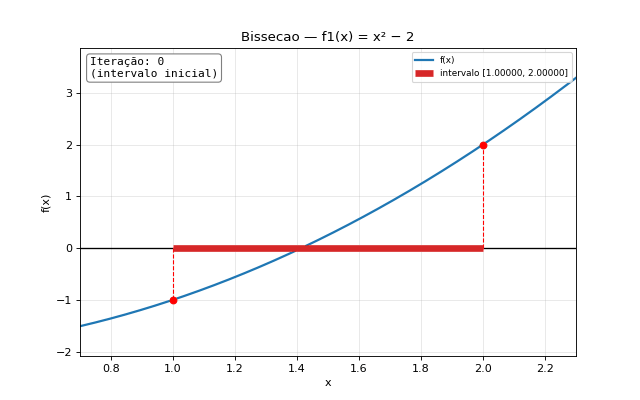

gifs/newton_f2.gif


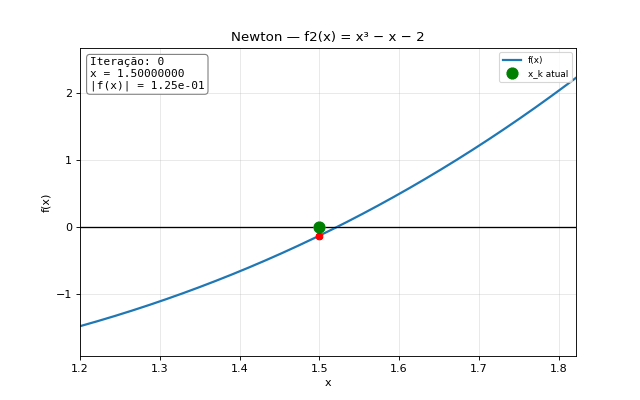

gifs/secante_f3.gif


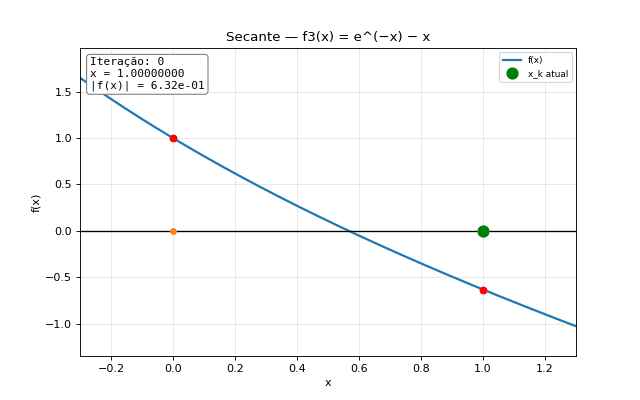

gifs/newton_f4.gif


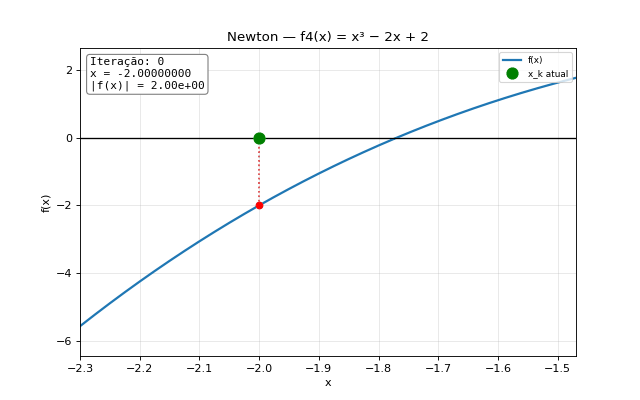

gifs/newton_f4_ciclo.gif


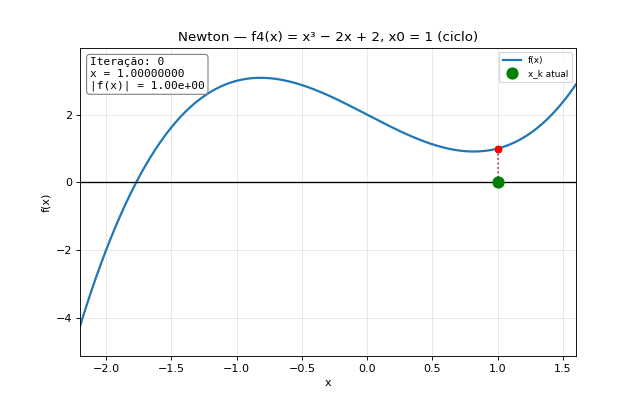

In [ ]:
# Visualização dos GIFs no notebook
for *_, arq, _ in animacoes:
    print(arq)
    display(Image(filename=arq))

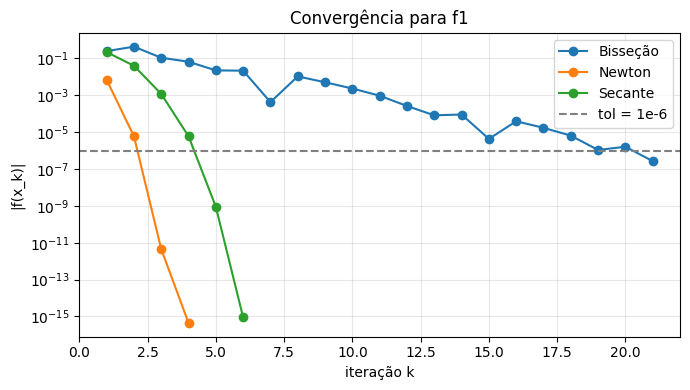

In [ ]:
# ============================================================
# Gráfico extra: velocidade de convergência em f1(x) = x² − 2
# ============================================================
r1 = resultados["f1(x) = x² − 2"]
plt.figure(figsize=(7, 4))
for nome_m, chave in [("Bisseção", "bissecao"), ("Newton", "newton"), ("Secante", "secante")]:
    res_k = [max(abs(f1(x)), 1e-17) for x in r1[chave]["historico"]]
    plt.semilogy(range(1, len(res_k) + 1), res_k, "o-", label=nome_m)
plt.axhline(TOL, color="gray", ls="--", label="tol = 1e-6")
plt.xlabel("iteração k"); plt.ylabel("|f(x_k)|"); plt.title("Convergência para f1")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("convergencia_f1.png", dpi=120); plt.show()

### Análise dos resultados
**Raízes encontradas.** $f_1$: $r\approx1{,}41421356$ ($\sqrt2$); $f_2$: $r\approx1{,}52137971$; $f_3$: $r\approx0{,}56714329$; $f_4$: $r\approx-1{,}76929235$ (única raiz real, pois o mínimo local de $f_4$, em $x\approx0{,}816$, vale $\approx0{,}91>0$). Os três métodos concordaram em todas as funções, com $|f(x)|$ final abaixo de $10^{-6}$.

**Custo e velocidade.** Com os valores sugeridos, a bisseção precisou de 20 a 22 iterações (o intervalo cai à metade a cada passo: convergência **linear**, e o número de iterações depende só da largura do intervalo e da tolerância). Newton precisou de 3 a 4 e a secante de 5 a 7 (convergência **superlinear**; ordem 2 para Newton e ≈ 1,618 para a secante). O gráfico de convergência de $f_1$ mostra essa diferença: o resíduo de Newton e da secante despenca, o da bisseção decai de forma regular.

**Robustez × rapidez.**
* *Bisseção:* só exige $f$ contínua e troca de sinal. Sempre converge nesse caso, mas é a mais lenta. Falha se $f(a)f(b)>0$ (testado em $f_1$ com $[2,3]$).
* *Newton:* muito rápido perto da raiz, mas exige $f'$ e um bom ponto inicial. Falhou em $f_1$ com $x_0=0$ ($f_1'(0)=0$) e entrou em **ciclo** $1\to0\to1\to\cdots$ em $f_4$ com $x_0=1$, sem convergir em 100 iterações (ver `newton_f4_ciclo.gif`).
* *Secante:* não precisa da derivada e é quase tão rápida quanto Newton, mas pode falhar se $f(x_k)\approx f(x_{k-1})$ (denominador nulo), como em $f_2$ com $(0,1)$.

**Escolhas próprias justificadas.** Para $f_1$, usamos $[-2,-1]$ e $x_0=-1{,}5$ para obter a raiz negativa $-\sqrt2$ (há mudança de sinal: $f_1(-2)=2>0$, $f_1(-1)=-1<0$). Os demais testes (intervalo $[2,3]$, $x_0=0$, $x_0=1$ e $(0,1)$) foram escolhidos de propósito para exercitar a detecção de falhas.

**Conclusão.** Os métodos abertos (Newton e secante) são bem mais rápidos, mas dependem dos valores iniciais; a bisseção é lenta, porém garantida. Uma estratégia comum é usar algumas iterações da bisseção para chegar perto da raiz e concluir com Newton ou secante.

## Parte 4 — Painel de teste livre
Altere **apenas esta célula** para testar outra função, outros valores iniciais, outra tolerância ou outro máximo de iterações (em trigonometria, $x$ em radianos).

In [ ]:
# ============================================================
# PAINEL DE TESTE LIVRE — edite os valores abaixo
# ============================================================
def f_usuario(x):  return np.cos(x) - x          # função (use numpy: np.sin, np.exp, ...)
def df_usuario(x): return -np.sin(x) - 1         # derivada (só para Newton)

intervalo = (0, 1)        # bisseção
x0_newton = 0.5           # Newton
par_secante = (0, 1)      # secante
tol_u, max_iter_u = 1e-8, 50

res_b = bissecao(f_usuario, *intervalo, tol_u, max_iter_u)
res_n = newton(f_usuario, df_usuario, x0_newton, tol_u, max_iter_u)
res_s = secante(f_usuario, *par_secante, tol_u, max_iter_u)
for nome, r in [("Bisseção", res_b), ("Newton", res_n), ("Secante", res_s)]:
    print(f"{nome:9s} raiz = {r['raiz']:.10f} | |f| = {r['residuo']:.2e} | {r['mensagem']}")

# Para gerar um GIF deste teste, descomente:
# animar(f_usuario, res_n, "newton", "cos(x) − x", "gifs/teste_livre_newton.gif")
# display(Image(filename="gifs/teste_livre_newton.gif"))

Bisseção  raiz = 0.7390851304 | |f| = 4.72e-09 | Convergiu em 27 iterações
Newton    raiz = 0.7390851332 | |f| = 0.00e+00 | Convergiu em 4 iterações
Secante   raiz = 0.7390851332 | |f| = 0.00e+00 | Convergiu em 6 iterações


## Parte 5 — Exportação dos arquivos para o dashboard (Mathcha)
Gera `resultados.csv`, uma imagem da tabela (`tabela_resultados.png`), a tabela em Markdown (para copiar) e um `.zip` com GIFs + tabela + gráfico.

In [ ]:
# ============================================================
# Exportação
# ============================================================
import shutil

df_resultados.to_csv("resultados.csv", index=False, encoding="utf-8-sig")
df_extras.to_csv("resultados_extras.csv", index=False, encoding="utf-8-sig")

# Imagem da tabela principal
fig, ax = plt.subplots(figsize=(13, 0.5 * (len(df_resultados) + 2)))
ax.axis("off")
tab = ax.table(cellText=df_resultados.values, colLabels=df_resultados.columns,
               loc="center", cellLoc="center")
tab.auto_set_font_size(False); tab.set_fontsize(9); tab.scale(1, 1.4)
tab.auto_set_column_width(list(range(len(df_resultados.columns))))
for j in range(len(df_resultados.columns)):
    tab[0, j].set_facecolor("#dbe9f3"); tab[0, j].set_text_props(weight="bold")
plt.savefig("tabela_resultados.png", dpi=150, bbox_inches="tight"); plt.close(fig)

# Tabela em Markdown (copiar e colar)
cab = "| " + " | ".join(df_resultados.columns) + " |\n|" + "---|" * len(df_resultados.columns)
corpo = "\n".join("| " + " | ".join(map(str, r)) + " |" for r in df_resultados.values)
print(cab + "\n" + corpo)

# Pacote .zip
os.makedirs("entrega", exist_ok=True)
for arq in ["resultados.csv", "resultados_extras.csv", "tabela_resultados.png", "convergencia_f1.png"]:
    shutil.copy(arq, "entrega")
shutil.copytree("gifs", "entrega/gifs", dirs_exist_ok=True)
shutil.make_archive("atividade3_entrega", "zip", "entrega")

try:                                      # download automático no Colab
    from google.colab import files
    files.download("atividade3_entrega.zip")
except ImportError:
    print("Arquivo gerado: atividade3_entrega.zip")

| Função | Método | Valores iniciais | Raiz aproximada | |f(x)| final | Iterações/resultado |
|---|---|---|---|---|---|
| f1(x) = x² − 2 | Bisseção | [1, 2] | 1.41421366 | 2.69e-07 | Convergiu em 21 iterações |
| f1(x) = x² − 2 | Newton | x0 = 1.5 | 1.41421356 | 4.44e-16 | Convergiu em 4 iterações |
| f1(x) = x² − 2 | Secante | (1, 2) | 1.41421356 | 8.88e-16 | Convergiu em 6 iterações |
| f2(x) = x³ − x − 2 | Bisseção | [1, 2] | 1.52137971 | 1.45e-08 | Convergiu em 22 iterações |
| f2(x) = x³ − x − 2 | Newton | x0 = 1.5 | 1.52137971 | 4.53e-14 | Convergiu em 3 iterações |
| f2(x) = x³ − x − 2 | Secante | (1, 2) | 1.52137971 | 1.84e-14 | Convergiu em 7 iterações |
| f3(x) = e^(−x) − x | Bisseção | [0, 1] | 0.56714344 | 2.35e-07 | Convergiu em 20 iterações |
| f3(x) = e^(−x) − x | Newton | x0 = 0.5 | 0.56714329 | 4.44e-15 | Convergiu em 3 iterações |
| f3(x) = e^(−x) − x | Secante | (0, 1) | 0.56714329 | 1.24e-13 | Convergiu em 5 iterações |
| f4(x) = x³ − 2x + 2 | Bisseção | [-2, -1] | 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>